In [21]:
from ml.dataset import get_dataloaders
from ml.models import Conv1Layer, Conv2Layer, Conv3Layer, Conv4Layer, Conv5Layer, Conv4LayerDropout, Conv4LayerDropoutBN
from ml.visualization import plot_results, summarize_results, compare_models, plot_dropout_visualization
from ml.train import Trainer
from ml.utils import *

%load_ext autoreload
%autoreload 2

import logging
import torch
import torch.optim as optim
from torch import nn
import gc

logger = logging.getLogger("Main")
logging.basicConfig(
    filename="logger.log",
    filemode="w",
    level=logging.INFO,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
torch.manual_seed(42)
torch.use_deterministic_algorithms(True)

if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

train_loader, val_loader, test_loader = get_dataloaders()

In [3]:
def run_experiment(
        model: nn.Module,
        model_name: str,
        lr: float = 0.001,
        max_epochs: int = 20,
        patience: int = 5,
) -> tuple[float, float, Trainer]:

    loss_fn  = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr = lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, "min", patience=2)

    trainer = Trainer(
        model = model,
        model_name = model_name,
        loss_fn = loss_fn,
        optimizer = optimizer,
        train_loader = train_loader,
        val_loader = val_loader,
        device = device,
        logger=logger,
        scheduler = scheduler,
    )

    val_loss, val_acc = trainer.train_and_validate(max_epochs = max_epochs, patience = patience)

    return val_loss, val_acc, trainer

In [30]:
def run_experiments(exps: list[Experiment], visualize = False, max_epochs: int = 20, patience: int = 5):
    for exp in exps:
        model = exp.model_cls(**exp.kwargs)

        val_loss, val_acc, trainer = run_experiment(
            model = model, model_name = exp.model_name, max_epochs = max_epochs, patience = patience
        )
        print(f"{exp.model_name}: validation loss: {val_loss:.4f}, validation accuracy: {val_acc:.4f}")

        if visualize:
            plot_results(progress = trainer.progress, model_name = exp.model_name)
        exp.progress = trainer.progress

        del model
        del trainer
        gc.collect()
        if torch.mps.is_available():
            torch.mps.empty_cache()


In [5]:
try:
    all_experiments = load_experiments()
except FileNotFoundError:
    all_experiments = []
except json.JSONDecodeError:
    all_experiments = []

Conv1_32: validation loss: 2.3080, validation accuracy: 0.5723


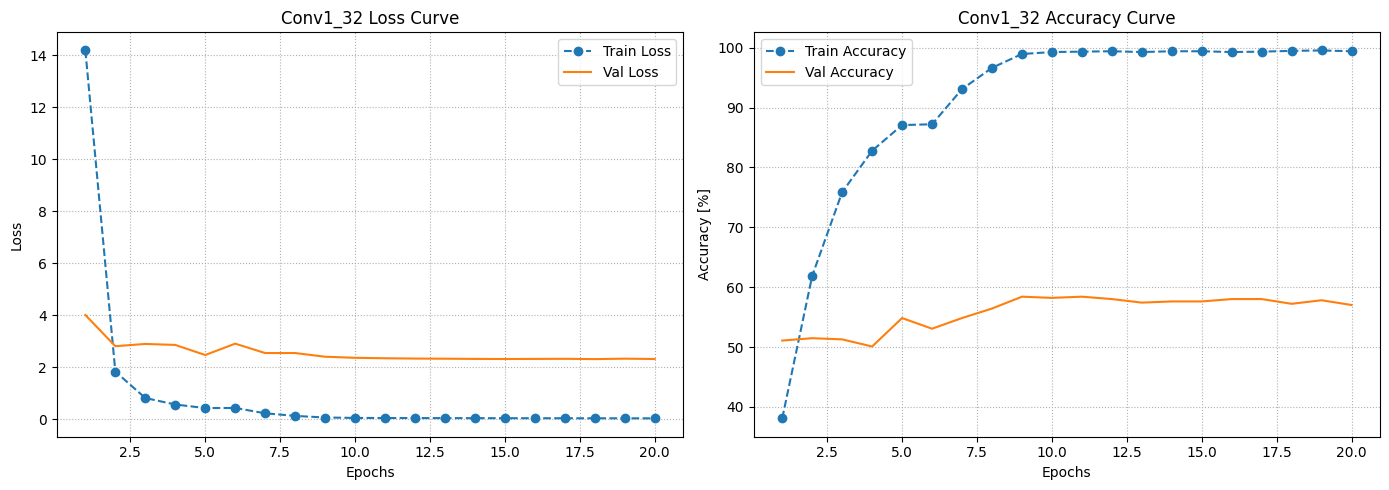

Conv1_64: validation loss: 3.1232, validation accuracy: 0.5723


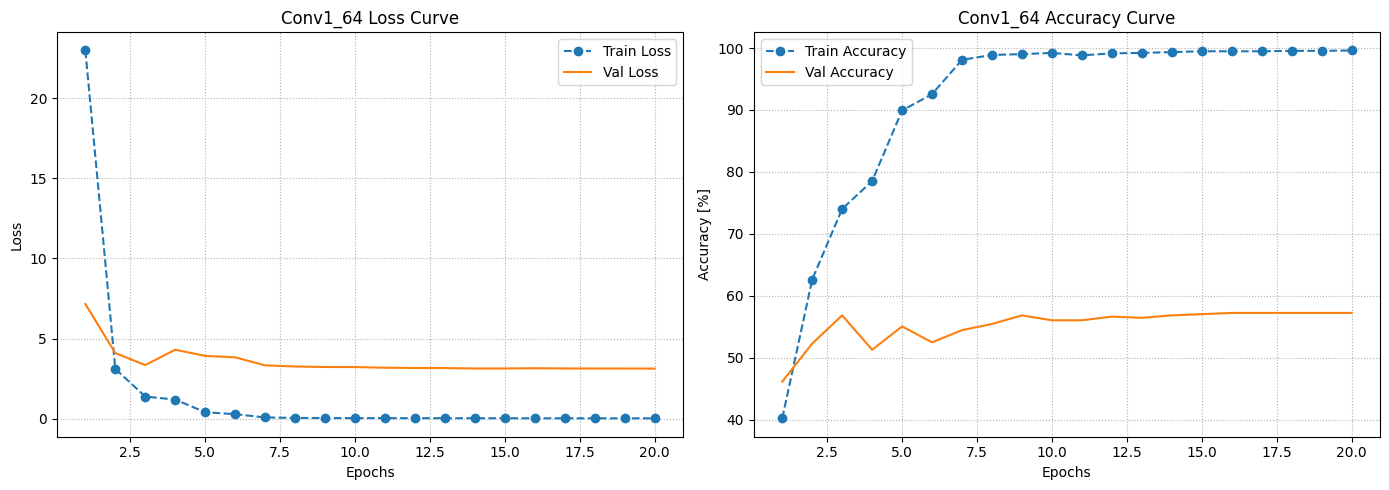

2 Experiments saved to experiments.json successfully


In [6]:
experiments = [
    Experiment("Conv1_32", Conv1Layer, {"n1" : 32}),
    Experiment("Conv1_64", Conv1Layer, {"n1" : 64}),
]

run_experiments(experiments, True)
all_experiments.extend(experiments)
save_experiments(all_experiments)

In [7]:
experiments2 = [
    Experiment("Conv2_16_32", Conv2Layer, {"n1" : 16, "n2" : 32}),
    Experiment("Conv2_32_64", Conv2Layer, {"n1" : 32, "n2" : 64}),
    Experiment("Conv2_32_32", Conv2Layer, {"n1" : 32, "n2" : 32}),
]
run_experiments(experiments2, False)
all_experiments.extend(experiments2)
save_experiments(all_experiments)

Conv2_16_32: validation loss: 1.2030, validation accuracy: 0.5802
Conv2_32_64: validation loss: 1.2903, validation accuracy: 0.5465
Conv2_32_32: validation loss: 1.2531, validation accuracy: 0.5604
5 Experiments saved to experiments.json successfully


In [8]:
experiments3 = [
    Experiment("Conv3_16_32_64", Conv3Layer, {"n1" : 16, "n2" : 32,"n3" : 64}),
    Experiment("Conv3_32_64_128", Conv3Layer, {"n1" : 32, "n2" : 64, "n3" : 128}),
]
run_experiments(experiments3, False)
all_experiments.extend(experiments3)
save_experiments(all_experiments)

Conv3_16_32_64: validation loss: 1.1056, validation accuracy: 0.5960
Conv3_32_64_128: validation loss: 1.1035, validation accuracy: 0.6337
7 Experiments saved to experiments.json successfully


In [9]:
experiments4 = [
    Experiment("Conv4_16_32_64_128", Conv4Layer, {"n1" : 16,"n2" : 32,"n3" : 64, "n4" : 128}),
    Experiment("Conv4_32_64_128_256", Conv4Layer, {"n1" : 32,"n2" : 64, "n3" : 128, "n4" : 256}),
]
run_experiments(experiments4, False)
all_experiments.extend(experiments4)
save_experiments(all_experiments)

Conv4_16_32_64_128: validation loss: 1.1137, validation accuracy: 0.6139
Conv4_32_64_128_256: validation loss: 0.9973, validation accuracy: 0.6297
9 Experiments saved to experiments.json successfully


In [10]:
experiments5 = [
    Experiment("Conv5_16_32_64_128_256", Conv5Layer, {"n1" : 16,"n2" : 32,"n3" : 64, "n4" : 128,"n5" : 256}),
    Experiment("Conv5_32_64_128_256_512", Conv5Layer, {"n1" : 32, "n2" : 64, "n3" : 128, "n4" : 256, "n5" : 512}),
]
run_experiments(experiments5, False)
all_experiments.extend(experiments5)
save_experiments(all_experiments)

Conv5_16_32_64_128_256: validation loss: 1.0933, validation accuracy: 0.6277
Conv5_32_64_128_256_512: validation loss: 1.0797, validation accuracy: 0.6554
11 Experiments saved to experiments.json successfully


In [11]:
summary = summarize_results(all_experiments)
display(summary)

,Model,Best Val Acc [%],Min Val Loss,Final Train Loss,Final Train Acc [%],Epochs
8,Conv4_32_64_128_256,67.33,0.9973,0.1621,96.04,10
9,Conv5_16_32_64_128_256,65.94,1.0933,0.1403,95.98,14
10,Conv5_32_64_128_256_512,65.74,1.0797,0.1209,97.23,13
7,Conv4_16_32_64_128,63.96,1.1137,0.0843,98.42,12
5,Conv3_16_32_64,63.56,1.1056,0.1465,96.64,9
6,Conv3_32_64_128,63.37,1.1035,0.0915,98.02,9
4,Conv2_32_32,60.40,1.2531,0.0936,98.42,9
2,Conv2_16_32,60.00,1.2030,0.1816,96.18,8
0,Conv1_32,58.42,2.3080,0.0290,99.41,20
3,Conv2_32_64,58.22,1.2903,0.1144,97.56,9


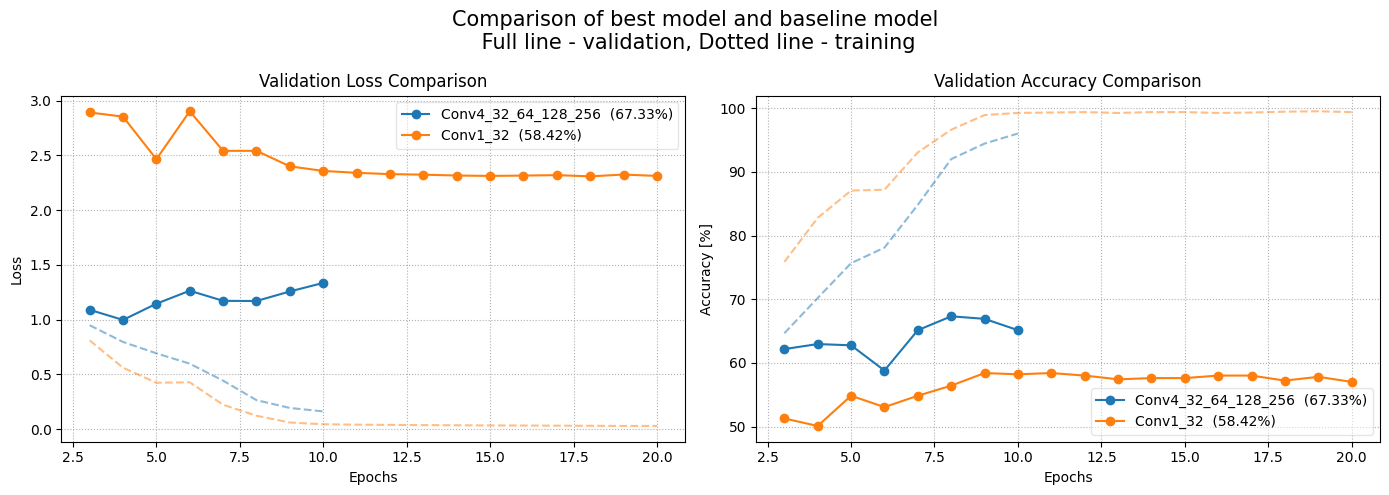

In [12]:
experiments = [min(all_experiments, key=lambda exp: min(r.val_loss for r in exp.progress)), all_experiments[0]]
compare_models(
    experiments,
    title = "Comparison of best model and baseline model",
    epoch_start=2,
    show_train=True,
)

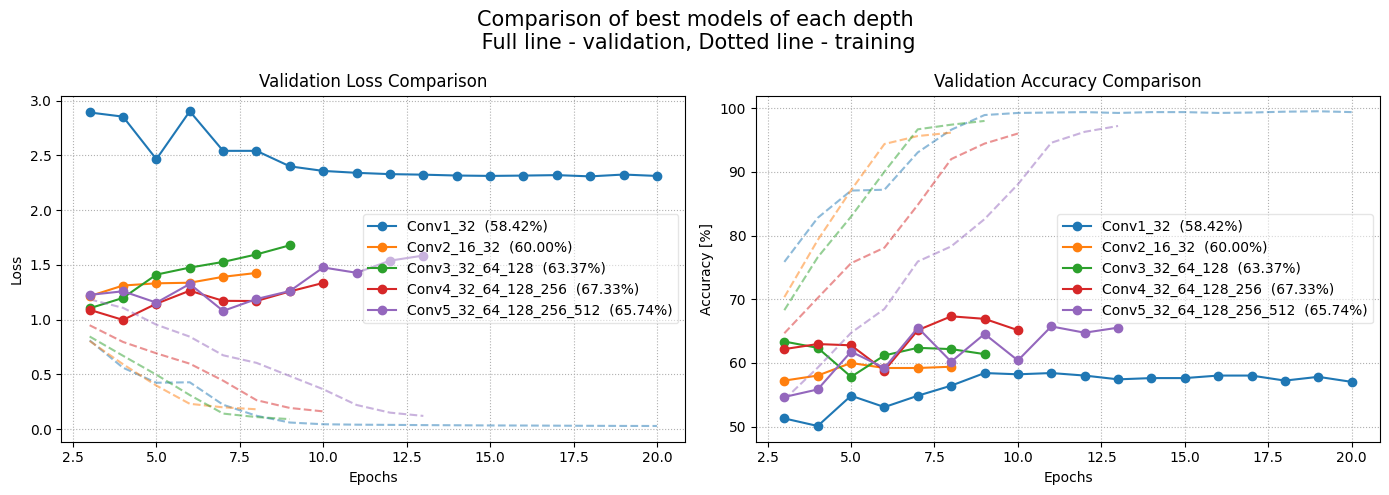

In [13]:
categories = ["Conv1", "Conv2", "Conv3", "Conv4", "Conv5"]
experiments_by_cat: list[list[Experiment]] = []
for cat in categories:
    exps = [e for e in all_experiments if e.model_name.startswith(cat)]
    if exps:
        experiments_by_cat.append(exps)

# gets best model for each category
best_experiments = [min(experiments, key=lambda exp: min(r.val_loss for r in exp.progress)) for experiments in experiments_by_cat]
compare_models(
    best_experiments,
    title = "Comparison of best models of each depth",
    epoch_start=2,
    show_train=True,
)

In [14]:
experiments_dropout = []
for useBN in [True, False]:
    for p in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]:
        if useBN:
            model_name = f"Conv4_32_64_128_256_BN_p={p}"
        else:
            model_name = f"Conv4_32_64_128_256_p={p}"
        model_cls = Conv4LayerDropoutBN if useBN else Conv4LayerDropout
        kwargs = {"n1" : 32,"n2" : 64, "n3" : 128, "n4" : 256, "p" : p}

        exp = Experiment(
            model_name, model_cls, kwargs
        )
        experiments_dropout.append(exp)

run_experiments(experiments_dropout, False)
all_experiments.extend(experiments_dropout)
save_experiments(all_experiments)

Conv4_32_64_128_256_BN_p=0.0: validation loss: 1.4069, validation accuracy: 0.6376
Conv4_32_64_128_256_BN_p=0.1: validation loss: 1.9010, validation accuracy: 0.6277
Conv4_32_64_128_256_BN_p=0.2: validation loss: 1.8502, validation accuracy: 0.6574
Conv4_32_64_128_256_BN_p=0.3: validation loss: 1.9502, validation accuracy: 0.6317
Conv4_32_64_128_256_BN_p=0.4: validation loss: 1.5730, validation accuracy: 0.6178
Conv4_32_64_128_256_BN_p=0.5: validation loss: 1.9803, validation accuracy: 0.6218
Conv4_32_64_128_256_p=0.0: validation loss: 1.1371, validation accuracy: 0.5980
Conv4_32_64_128_256_p=0.1: validation loss: 1.1563, validation accuracy: 0.6139
Conv4_32_64_128_256_p=0.2: validation loss: 1.0814, validation accuracy: 0.6455
Conv4_32_64_128_256_p=0.3: validation loss: 1.0500, validation accuracy: 0.6733
Conv4_32_64_128_256_p=0.4: validation loss: 1.1647, validation accuracy: 0.6812
Conv4_32_64_128_256_p=0.5: validation loss: 1.0261, validation accuracy: 0.6614
23 Experiments saved t

In [18]:
summary = summarize_results(experiments_dropout)
display(summary)

,Model,Best Val Acc [%],Min Val Loss,Final Train Loss,Final Train Acc [%],Epochs
10,Conv4_32_64_128_256_p=0.4,68.12,1.1647,0.2644,92.16,14
9,Conv4_32_64_128_256_p=0.3,67.72,1.0500,0.1939,94.00,11
11,Conv4_32_64_128_256_p=0.5,66.93,1.0261,0.1435,95.98,11
2,Conv4_32_64_128_256_BN_p=0.2,66.34,1.8502,0.1633,95.19,20
0,Conv4_32_64_128_256_BN_p=0.0,65.74,1.4069,0.2445,92.35,13
8,Conv4_32_64_128_256_p=0.2,65.74,1.0814,0.2394,93.21,10
6,Conv4_32_64_128_256_p=0.0,64.75,1.1371,0.3049,90.51,9
7,Conv4_32_64_128_256_p=0.1,64.55,1.1563,0.3181,89.85,9
3,Conv4_32_64_128_256_BN_p=0.3,63.96,1.9502,0.1899,93.21,20
1,Conv4_32_64_128_256_BN_p=0.1,63.56,1.9010,0.1588,95.25,20


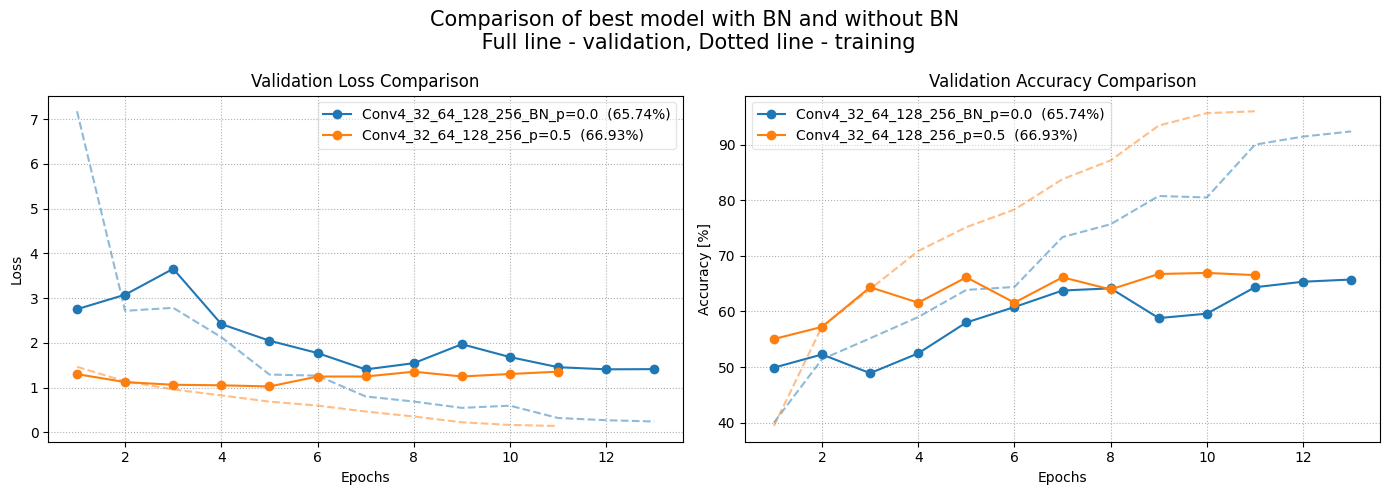

In [20]:
experiments_bn = [e for e in experiments_dropout if "BN" in e.model_name]
experiments_no_bn = [e for e in experiments_dropout if not "BN" in e.model_name]

# gets best model for each category
best_experiments = [min(experiments, key=lambda exp: min(r.val_loss for r in exp.progress)) for experiments in [experiments_bn, experiments_no_bn]]
compare_models(
    best_experiments,
    title = "Comparison of best model with BN and without BN",
    show_train=True,
)

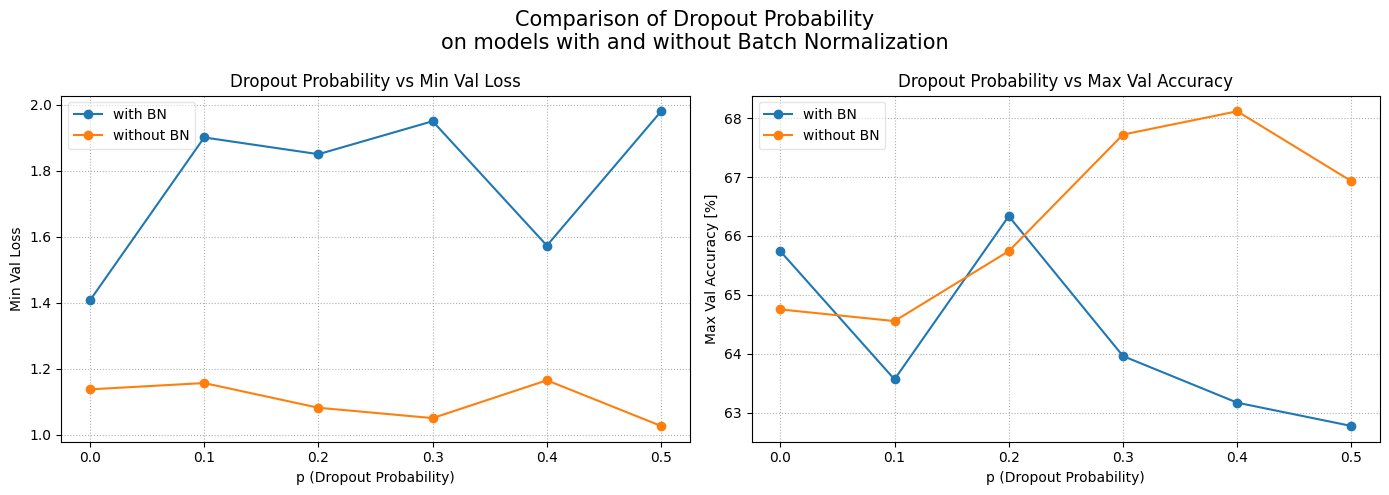

In [28]:
plot_dropout_visualization(experiments_bn, experiments_no_bn)

Conv4_32_64_128_256_Augment: validation loss: 0.8873, validation accuracy: 0.6970


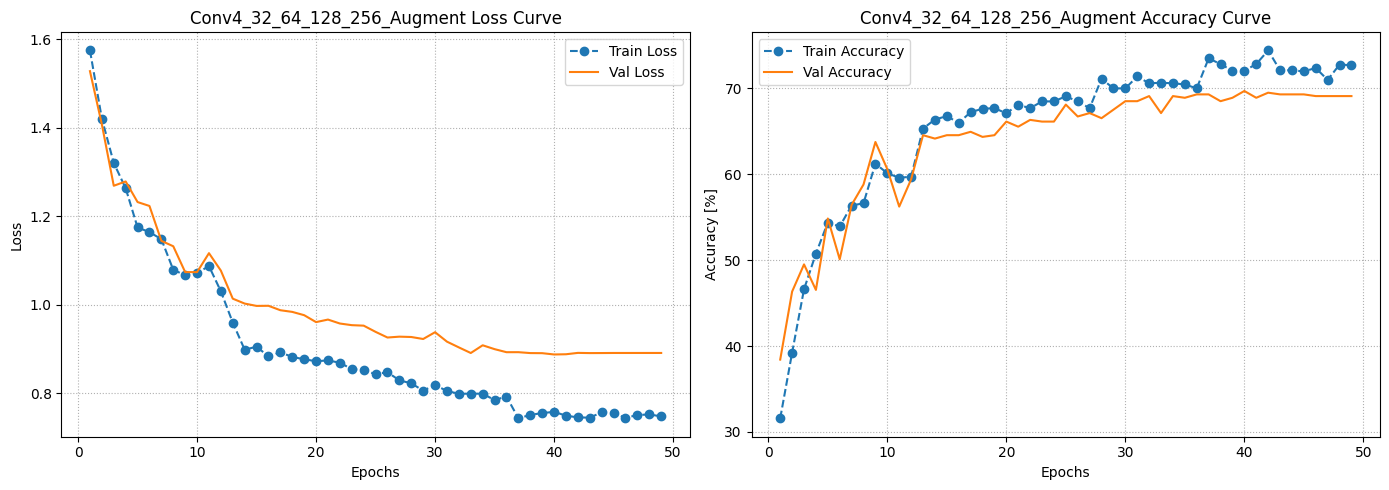

25 Experiments saved to experiments.json successfully


In [32]:
train_loader, val_loader, test_loader = get_dataloaders(use_data_augmentation=True)
experiments_augment = [
    Experiment("Conv4_32_64_128_256_Augment", Conv4LayerDropout, {"n1" : 32,"n2" : 64, "n3" : 128, "n4" : 256, "p" : 0.5,})
]

run_experiments(experiments_augment, True, max_epochs=75, patience=8)
all_experiments.extend(experiments_augment)
save_experiments(all_experiments)

In [44]:
first_exp = all_experiments[0]
best_basic_exp = [exp for exp in all_experiments if exp.model_name == "Conv4_32_64_128_256"][0]
best_with_dropout = [exp for exp in all_experiments if exp.model_name == "Conv4_32_64_128_256_p=0.5"][0]
best_with_augment = [exp for exp in all_experiments if exp.model_name == "Conv4_32_64_128_256_Augment"][0]

experiments_to_compare = [first_exp, best_basic_exp, best_with_dropout, best_with_augment]

In [45]:
[exp.model_name for exp in experiments_to_compare]

['Conv1_32',
 'Conv4_32_64_128_256',
 'Conv4_32_64_128_256_p=0.5',
 'Conv4_32_64_128_256_Augment']

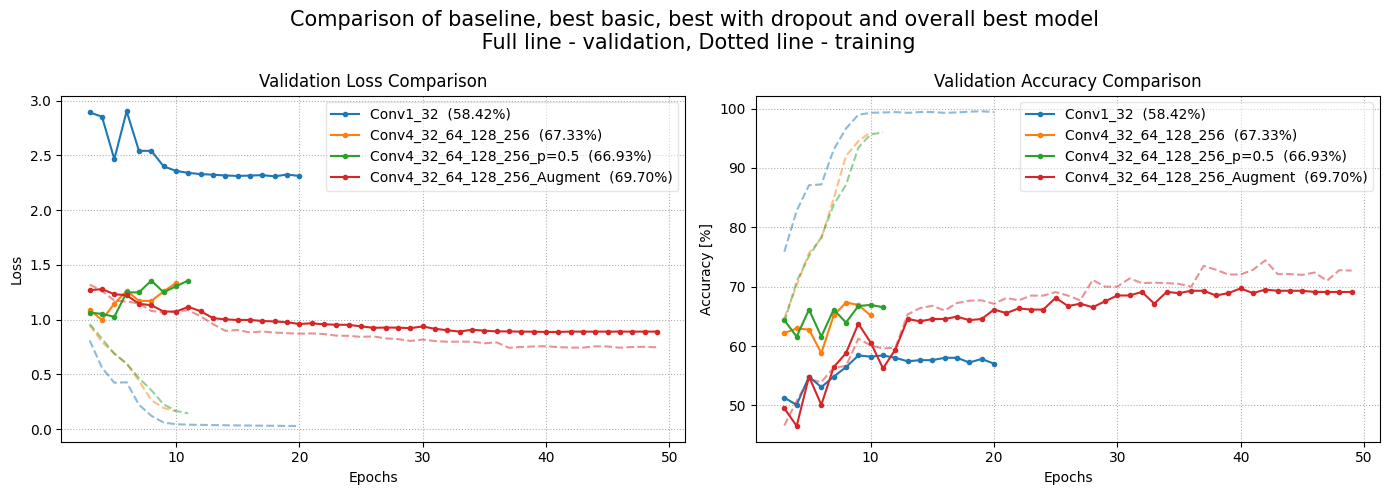

In [46]:
compare_models(
    experiments_to_compare,
    title = "Comparison of baseline, best basic, best with dropout and overall best model",
    show_train=True,
    epoch_start=2,
)